In [1]:
%%capture
import numpy as np
import pandas as pd
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [2]:
!pip install pennylane
!pip install torchinfo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 62.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 78.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 114.4 MB/s eta 0:00:0000:0100:01


In [3]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from datetime import timedelta

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, ConcatDataset
from torchvision import transforms, models

from sklearn.metrics import *
from tqdm.auto import tqdm

import pennylane as qml
from torchinfo import summary

# Precision settings
np.set_printoptions(precision=3)
torch.set_printoptions(precision=3)

In [4]:
IMG_SIZE = 224
BATCH_SIZE = 6  
EPOCHS = 25
LR = 0.00005      
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [5]:
CSV_PATH = "/kaggle/input/datasets/farjanakabirsamanta/skin-cancer-dataset/HAM10000_metadata.csv"
IMG_DIR = "/kaggle/input/datasets/farjanakabirsamanta/skin-cancer-dataset/Skin Cancer/Skin Cancer"

## Data Augmentation Strategy

Classes sorted alphabetically (matching `sorted(df['dx'].unique())`):
- Index 0: **akiec** (327) — Minority
- Index 1: **bcc** (514) — Minority
- Index 2: **bkl** (1099) — Majority
- Index 3: **df** (115) — Minority
- Index 4: **mel** (1113) — Majority
- Index 5: **nv** (6705) — Majority
- Index 6: **vasc** (142) — Minority

**Minority classes** (akiec, bcc, df, vasc): 4 sets total
  1. Original images
  2. Rotation augmented
  3. Zoom augmented
  4. Brightness augmented

**Majority classes** (bkl, mel, nv): 2 sets total
  1. Original images
  2. Rotation augmented

## Define Transforms

In [6]:
# ─── Base transform (used for all original sets) ───────────────────────────────
base_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# ─── Augmentation 1: Rotation only (for majority classes) ─────────────────────
rotation_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(degrees=30),
    transforms.ToTensor(),
])

# ─── Augmentation 2: Zoom (random resized crop simulates zoom) ─────────────────
zoom_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomResizedCrop(size=IMG_SIZE, scale=(0.7, 1.0)),
    transforms.ToTensor(),
])

# ─── Augmentation 3: Brightness adjustment ─────────────────────────────────────
brightness_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ColorJitter(brightness=0.5, contrast=0.3),
    transforms.ToTensor(),
])

print("Transforms defined:")
print("  base_transform      : Resize → ToTensor")
print("  rotation_transform  : Resize → RandomRotation(±30°) → ToTensor")
print("  zoom_transform      : Resize → RandomResizedCrop(scale 0.7-1.0) → ToTensor")
print("  brightness_transform: Resize → ColorJitter(brightness±0.5) → ToTensor")

Transforms defined:
  base_transform      : Resize → ToTensor
  rotation_transform  : Resize → RandomRotation(±30°) → ToTensor
  zoom_transform      : Resize → RandomResizedCrop(scale 0.7-1.0) → ToTensor
  brightness_transform: Resize → ColorJitter(brightness±0.5) → ToTensor


## Dataset Class

In [7]:
class SkinCancerDataset(Dataset):
    """
    Generic dataset that loads images for a given list of classes
    and applies the specified transform.
    """
    def __init__(self, csv_file, img_dir, transform=None, filter_classes=None, class_to_idx=None):
        """
        Args:
            csv_file      : Path to HAM10000 metadata CSV.
            img_dir       : Directory containing the .jpg images.
            transform     : torchvision transform to apply.
            filter_classes: List of class names to include (None = all classes).
            class_to_idx  : Shared label mapping so all subsets use the same indices.
        """
        df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

        # Use provided mapping or build a global one
        if class_to_idx is None:
            all_classes = sorted(df['dx'].unique())
            self.class_to_idx = {cls: i for i, cls in enumerate(all_classes)}
        else:
            self.class_to_idx = class_to_idx

        self.classes = list(self.class_to_idx.keys())

        # Filter to requested classes
        if filter_classes is not None:
            df = df[df['dx'].isin(filter_classes)]

        df['label'] = df['dx'].map(self.class_to_idx)

        self.image_paths, self.labels = [], []
        for _, row in df.iterrows():
            path = os.path.join(self.img_dir, row['image_id'] + ".jpg")
            if os.path.exists(path):
                self.image_paths.append(path)
                self.labels.append(row['label'])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

## Build Augmented Datasets & Visualise Augmentations

In [8]:
# ─── Class definitions ─────────────────────────────────────────────────────────
# Alphabetical sort matches sorted(df['dx'].unique())
# akiec(0) bcc(1) bkl(2) df(3) mel(4) nv(5) vasc(6)
MINORITY_CLASSES = ['akiec', 'bcc', 'df', 'vasc']   # 4 sets each
MAJORITY_CLASSES = ['bkl', 'mel', 'nv']              # 2 sets each
ALL_CLASSES      = sorted(MINORITY_CLASSES + MAJORITY_CLASSES)

# Shared label mapping (all datasets must use the same indices)
CLASS_TO_IDX = {cls: i for i, cls in enumerate(ALL_CLASSES)}
CLASSES      = list(CLASS_TO_IDX.keys())
num_classes  = len(CLASSES)

print("Class → Index mapping:")
for cls, idx in CLASS_TO_IDX.items():
    role = 'MINORITY' if cls in MINORITY_CLASSES else 'MAJORITY'
    print(f"  {idx}: {cls:8s} [{role}]")

Class → Index mapping:
  0: akiec    [MINORITY]
  1: bcc      [MINORITY]
  2: bkl      [MAJORITY]
  3: df       [MINORITY]
  4: mel      [MAJORITY]
  5: nv       [MAJORITY]
  6: vasc     [MINORITY]


In [9]:
# ─── Helper to build dataset ───────────────────────────────────────────────────
def make_ds(filter_classes, transform):
    return SkinCancerDataset(
        CSV_PATH, IMG_DIR,
        transform=transform,
        filter_classes=filter_classes,
        class_to_idx=CLASS_TO_IDX
    )

# ─── Minority: 4 sets ──────────────────────────────────────────────────────────
min_original   = make_ds(MINORITY_CLASSES, base_transform)       # Set 1: original
min_rotation   = make_ds(MINORITY_CLASSES, rotation_transform)   # Set 2: rotated
min_zoom       = make_ds(MINORITY_CLASSES, zoom_transform)       # Set 3: zoomed
min_brightness = make_ds(MINORITY_CLASSES, brightness_transform) # Set 4: brightness

# ─── Majority: 2 sets ──────────────────────────────────────────────────────────
maj_original   = make_ds(MAJORITY_CLASSES, base_transform)       # Set 1: original
maj_rotation   = make_ds(MAJORITY_CLASSES, rotation_transform)   # Set 2: rotated

print(f"Minority class sizes  — original: {len(min_original):,} | ×4 after concat: {4*len(min_original):,}")
print(f"Majority class sizes  — original: {len(maj_original):,} | ×2 after concat: {2*len(maj_original):,}")

Minority class sizes  — original: 1,098 | ×4 after concat: 4,392
Majority class sizes  — original: 8,917 | ×2 after concat: 17,834


### Visualisation — How Does Each Augmentation Look?
We take the **same source image** and show it through all four transforms side-by-side for a minority class, then both transforms for a majority class.

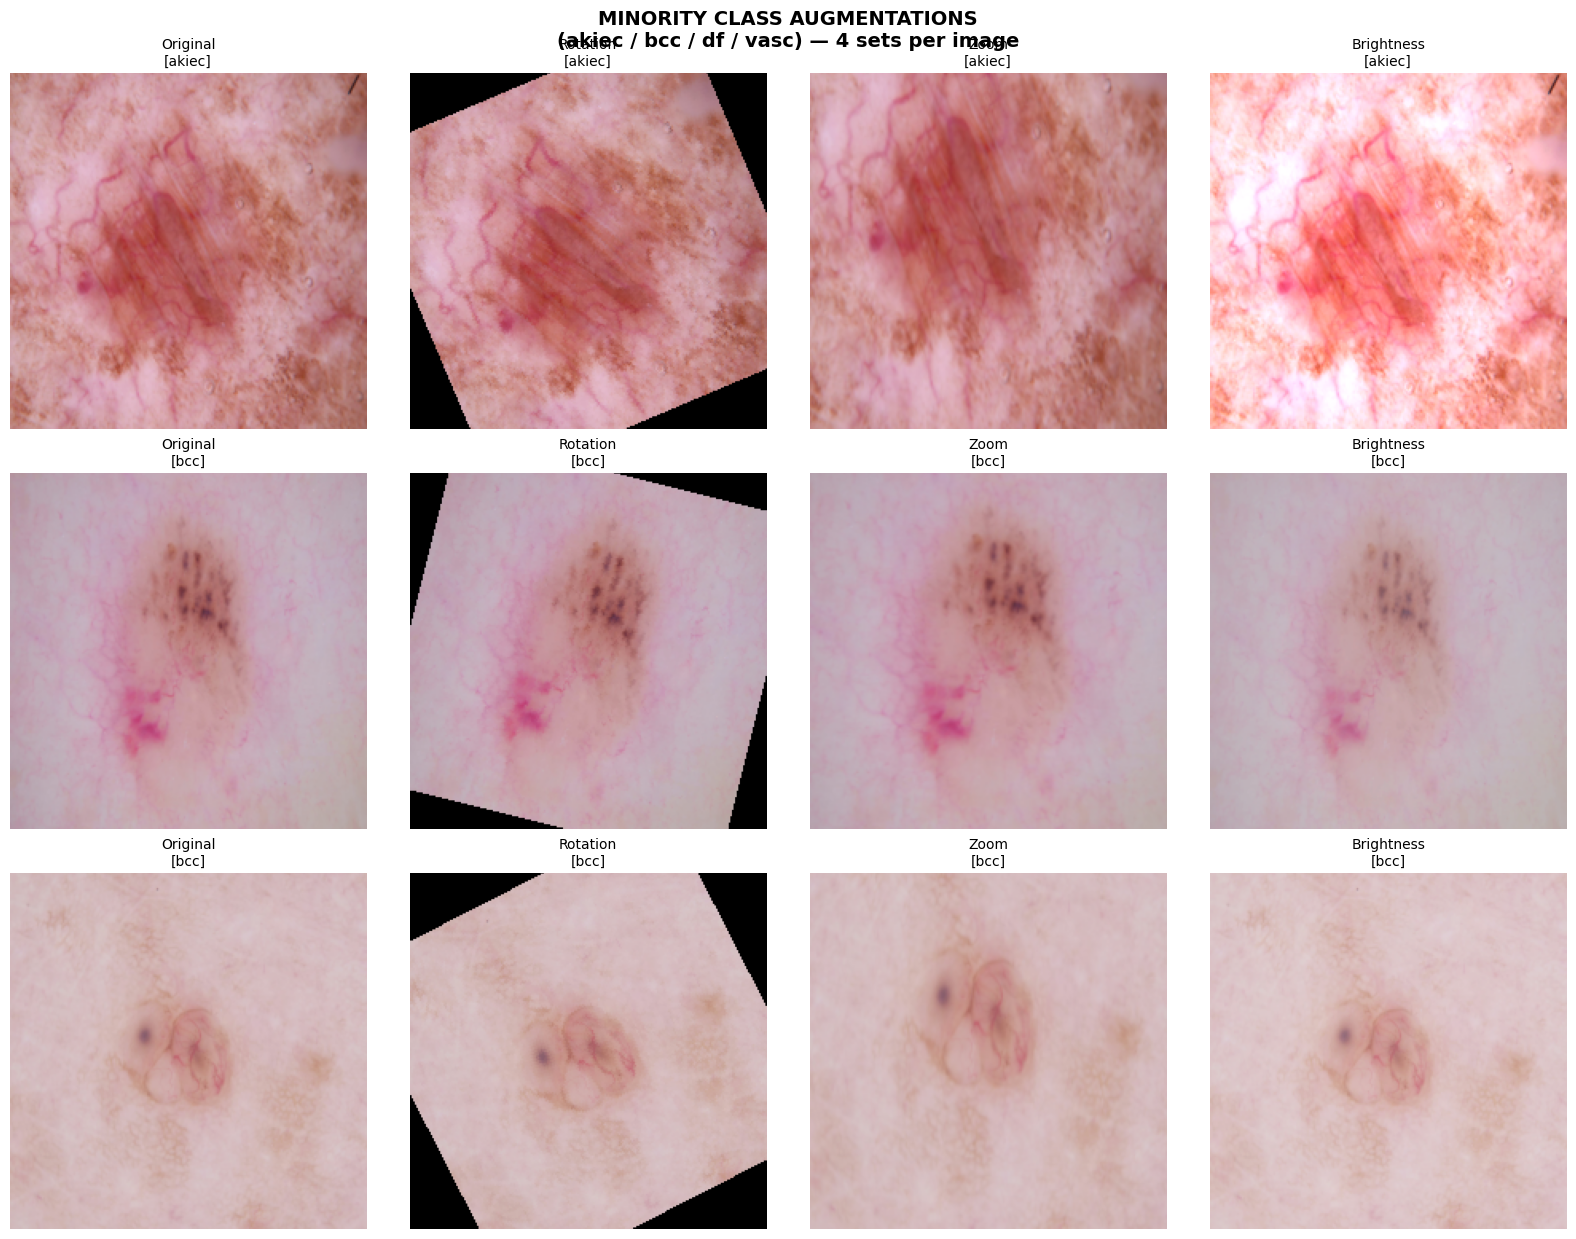

↑ Minority augmentation preview saved to /kaggle/working/minority_augmentations.png


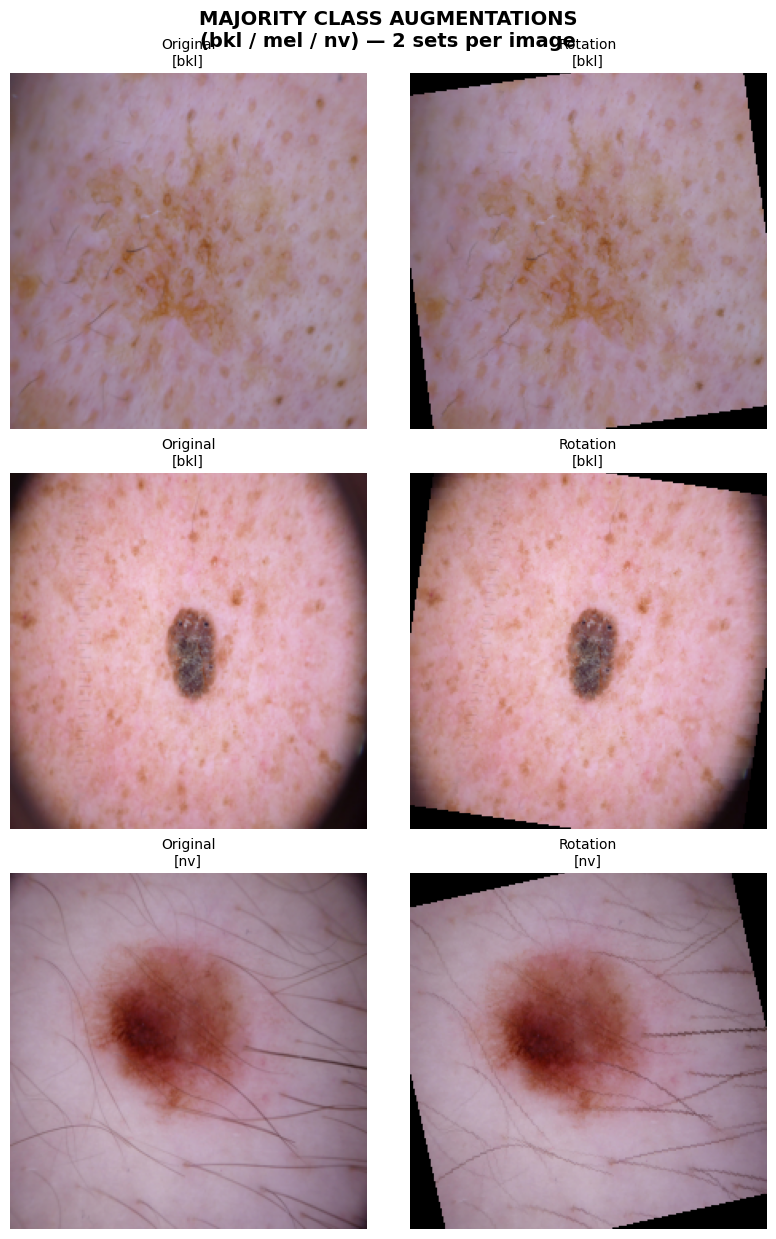

↑ Majority augmentation preview saved to /kaggle/working/majority_augmentations.png


In [10]:
def show_augmentation_grid(csv_path, img_dir, class_to_idx,
                           minority_classes, majority_classes,
                           n_examples=3):
    """
    Picks n_examples images from a minority class and n_examples from a
    majority class, then renders them through each augmentation pipeline.
    """
    df = pd.read_csv(csv_path)

    # --- collect sample paths ---
    minority_rows = df[df['dx'].isin(minority_classes)].sample(n_examples, random_state=7)
    majority_rows = df[df['dx'].isin(majority_classes)].sample(n_examples, random_state=7)

    min_transforms = [
        ('Original',   base_transform),
        ('Rotation',   rotation_transform),
        ('Zoom',       zoom_transform),
        ('Brightness', brightness_transform),
    ]
    maj_transforms = [
        ('Original',   base_transform),
        ('Rotation',   rotation_transform),
    ]

    def tensor_to_img(t):
        arr = t.permute(1, 2, 0).numpy()
        return np.clip(arr, 0, 1)

    # ── MINORITY GRID ──────────────────────────────────────────────────────────
    fig, axes = plt.subplots(n_examples, 4,
                             figsize=(16, 4 * n_examples),
                             constrained_layout=True)
    fig.suptitle('MINORITY CLASS AUGMENTATIONS\n'
                 '(akiec / bcc / df / vasc) — 4 sets per image',
                 fontsize=14, fontweight='bold', y=1.02)

    for r, (_, row) in enumerate(minority_rows.iterrows()):
        path = os.path.join(img_dir, row['image_id'] + '.jpg')
        pil_img = Image.open(path).convert('RGB')
        for c, (label, tfm) in enumerate(min_transforms):
            ax = axes[r, c] if n_examples > 1 else axes[c]
            ax.imshow(tensor_to_img(tfm(pil_img)))
            ax.set_title(f'{label}\n[{row["dx"]}]', fontsize=10)
            ax.axis('off')

    plt.savefig('/kaggle/working/minority_augmentations.png',
                dpi=100, bbox_inches='tight')
    plt.show()
    print("↑ Minority augmentation preview saved to /kaggle/working/minority_augmentations.png")

    # ── MAJORITY GRID ──────────────────────────────────────────────────────────
    fig2, axes2 = plt.subplots(n_examples, 2,
                               figsize=(8, 4 * n_examples),
                               constrained_layout=True)
    fig2.suptitle('MAJORITY CLASS AUGMENTATIONS\n'
                  '(bkl / mel / nv) — 2 sets per image',
                  fontsize=14, fontweight='bold', y=1.02)

    for r, (_, row) in enumerate(majority_rows.iterrows()):
        path = os.path.join(img_dir, row['image_id'] + '.jpg')
        pil_img = Image.open(path).convert('RGB')
        for c, (label, tfm) in enumerate(maj_transforms):
            ax = axes2[r, c] if n_examples > 1 else axes2[c]
            ax.imshow(tensor_to_img(tfm(pil_img)))
            ax.set_title(f'{label}\n[{row["dx"]}]', fontsize=10)
            ax.axis('off')

    plt.savefig('/kaggle/working/majority_augmentations.png',
                dpi=100, bbox_inches='tight')
    plt.show()
    print("↑ Majority augmentation preview saved to /kaggle/working/majority_augmentations.png")


show_augmentation_grid(
    CSV_PATH, IMG_DIR, CLASS_TO_IDX,
    MINORITY_CLASSES, MAJORITY_CLASSES,
    n_examples=3
)

## Combine & Split — Train / Val / Test

In [11]:
# ─── Concatenate all sets into one full augmented dataset ─────────────────────
full_dataset = ConcatDataset([
    # Minority: 4 sets
    min_original,
    min_rotation,
    min_zoom,
    min_brightness,
    # Majority: 2 sets
    maj_original,
    maj_rotation,
])

total = len(full_dataset)
print(f"Total images after augmentation: {total:,}")
print(f"  Minority contribution : {4 * len(min_original):,} ({4 * len(min_original)/total*100:.1f}%)")
print(f"  Majority contribution : {2 * len(maj_original):,} ({2 * len(maj_original)/total*100:.1f}%)")

# ─── 70 / 15 / 15 split (same ratio as original notebook) ────────────────────
train_size = int(0.70 * total)
val_size   = int(0.15 * total)
test_size  = total - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f"\nSplit sizes:  train={len(train_dataset):,}  val={len(val_dataset):,}  test={len(test_dataset):,}")

Total images after augmentation: 22,226
  Minority contribution : 4,392 (19.8%)
  Majority contribution : 17,834 (80.2%)

Split sizes:  train=15,558  val=3,333  test=3,335


## Quantum Circuit

In [12]:
n_qubits = 2
n_layers = 2

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):

    # DATA ENCODING (Angle Encoding)
    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)

    # VARIATIONAL LAYERS
    for l in range(n_layers):

        # Rotation layer
        for i in range(n_qubits):
            qml.RX(weights[l, i], wires=i)
            qml.RZ(weights[l, i], wires=i)

        # ENTANGLEMENT (chain + ring)
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i+1])
        qml.CNOT(wires=[n_qubits-1, 0])  # ring

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]


class QuantumLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(n_layers, n_qubits))

    def forward(self, x):
        outputs = []
        for i in range(x.shape[0]):
            out = quantum_circuit(x[i], self.weights)
            out = torch.stack(out).float()
            outputs.append(out)
        return torch.stack(outputs)

## Hybrid MobileNet Model

In [13]:
class HybridMobileNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        base = models.mobilenet_v2(weights="DEFAULT")
        self.features = base.features

        # Freeze 50%
        freeze_layers = len(self.features)//2
        for i in range(freeze_layers):
            for p in self.features[i].parameters():
                p.requires_grad = False

        # Quantum branch
        self.q_branch = nn.Sequential(
            nn.Conv2d(160, 40, 1),
            nn.BatchNorm2d(40),
            nn.ReLU(),

            nn.Conv2d(40, 16, 3, padding=1, dilation=2),
            nn.BatchNorm2d(16),
            nn.SiLU(),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1,1))
        )

        self.q_fc = nn.Linear(16, n_qubits)
        self.quantum = QuantumLayer()

        # Classical enhancement
        self.extra = nn.Sequential(
            nn.Conv2d(1280,128,1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.final_fc = nn.Linear(64 + n_qubits, num_classes)

    def forward(self,x):
        x = self.features[:17](x)

        # Quantum
        q = self.q_branch(x)
        q = torch.flatten(q,1)
        q = torch.tanh(self.q_fc(q))
        q = self.quantum(q)

        # Classical
        c = self.features[17:](x)
        c = self.extra(c)
        c = nn.functional.adaptive_avg_pool2d(c,(1,1))
        c = torch.flatten(c,1)

        out = torch.cat([c,q],dim=1)
        return self.final_fc(out)

In [14]:
model = HybridMobileNet(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 96.1MB/s]


## Training

In [15]:
def custom_metrics(y_pred, y_true, loss):
    y_pred = torch.argmax(y_pred,1)

    y_true = y_true.cpu().numpy()
    y_pred = y_pred.cpu().numpy()

    return {
        "loss": round(loss,3),
        "accuracy": round(accuracy_score(y_true,y_pred),3)
    }

In [16]:
train_hist = {"loss":[],"accuracy":[]}
val_hist   = {"loss":[],"accuracy":[]}

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    model.train()
    train_loss=0
    preds, labels = [],[]

    for x,y in tqdm(train_loader):
        x,y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out,y)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds.append(out)
        labels.append(y)

    preds  = torch.cat(preds)
    labels = torch.cat(labels)

    train_metrics = custom_metrics(preds,labels,train_loss/len(train_loader))
    train_hist["loss"].append(train_metrics["loss"])
    train_hist["accuracy"].append(train_metrics["accuracy"])

    print("Train:", {k:f"{v:.3f}" for k,v in train_metrics.items()})

    # VALIDATION
    model.eval()
    val_loss=0
    preds, labels = [],[]

    with torch.no_grad():
        for x,y in val_loader:
            x,y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out,y)

            val_loss += loss.item()
            preds.append(out)
            labels.append(y)

    preds  = torch.cat(preds)
    labels = torch.cat(labels)

    val_metrics = custom_metrics(preds,labels,val_loss/len(val_loader))
    val_hist["loss"].append(val_metrics["loss"])
    val_hist["accuracy"].append(val_metrics["accuracy"])

    print("Val:", {k:f"{v:.3f}" for k,v in val_metrics.items()})

    # Save model at epoch 15 and final epoch 25
    if epoch + 1 == 15:
        torch.save(model.state_dict(), "/kaggle/working/hybrid_model_epoch_15.pt")
        print("✓ Model saved at epoch 15")
    elif epoch + 1 == 25:
        torch.save(model.state_dict(), "/kaggle/working/hybrid_model_epoch_25_final.pt")
        print("✓ Model saved at epoch 25 (final)")


Epoch 1/25


  0%|          | 0/2593 [00:00<?, ?it/s]

Train: {'loss': '1.050', 'accuracy': '0.666'}
Val: {'loss': '0.651', 'accuracy': '0.781'}

Epoch 2/25


  0%|          | 0/2593 [00:00<?, ?it/s]

Train: {'loss': '0.721', 'accuracy': '0.764'}
Val: {'loss': '0.517', 'accuracy': '0.825'}

Epoch 3/25


...

Train: {'loss': '0.090', 'accuracy': '0.973'}
Val: {'loss': '0.185', 'accuracy': '0.944'}

Epoch 24/25


  0%|          | 0/2593 [00:00<?, ?it/s]

Train: {'loss': '0.095', 'accuracy': '0.970'}
Val: {'loss': '0.192', 'accuracy': '0.944'}

Epoch 25/25


  0%|          | 0/2593 [00:00<?, ?it/s]

Train: {'loss': '0.083', 'accuracy': '0.974'}
Val: {'loss': '0.177', 'accuracy': '0.943'}
✓ Model saved at epoch 25 (final)


## Training Curves

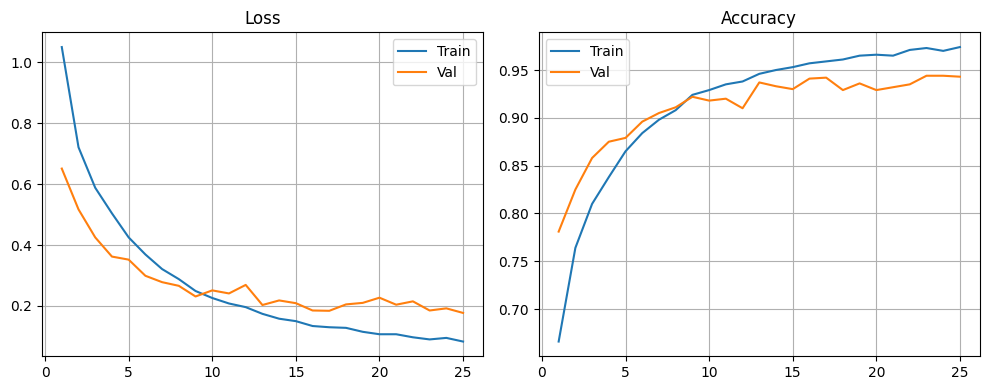

In [17]:
epochs = range(1,len(train_hist["loss"])+1)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(epochs,train_hist["loss"],label="Train")
plt.plot(epochs,val_hist["loss"],label="Val")
plt.title("Loss")
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(epochs,train_hist["accuracy"],label="Train")
plt.plot(epochs,val_hist["accuracy"],label="Val")
plt.title("Accuracy")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## Test Evaluation

In [18]:
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)

        all_preds.append(out)
        all_labels.append(y)

all_preds  = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

pred_classes = torch.argmax(all_preds, dim=1)

# Classification Report
report = classification_report(
    all_labels.cpu(),
    pred_classes.cpu(),
    target_names=CLASSES,
    digits=3
)

print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(report)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

       akiec      0.952     0.957     0.955       187
         bcc      0.938     0.969     0.953       325
         bkl      0.877     0.907     0.891       321
          df      0.981     0.945     0.963        55
         mel      0.898     0.797     0.844       310
          nv      0.969     0.969     0.969      2050
        vasc      0.870     1.000     0.930        87

    accuracy                          0.947      3335
   macro avg      0.926     0.935     0.929      3335
weighted avg      0.947     0.947     0.947      3335



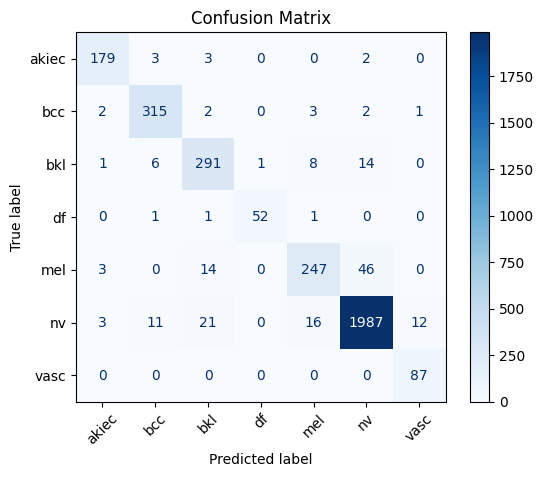

In [19]:
cm = confusion_matrix(all_labels.cpu(), pred_classes.cpu())

disp = ConfusionMatrixDisplay(cm, display_labels=CLASSES)
disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix")
plt.show()

## Parameter Summary

In [20]:
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print("\n" + "="*40)
print(f"{'Total Parameters:':<25} {total_params:,}")
print(f"{'Trainable Parameters:':<25} {trainable_params:,}")
print(f"{'Frozen Parameters:':<25} {frozen_params:,}")
print("="*40)


Total Parameters:         2,474,883
Trainable Parameters:     2,344,067
Frozen Parameters:        130,816
